# inicializacion

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
games = pd.read_csv("/datasets/games.csv", sep = ",")

In [3]:

games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [ ]:
# Reemplaza los nombres de las columnas (ponlos en minúsculas)

games.columns = games.columns.str.lower()
games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [ ]:
# Convierte las columnas 'year_of_release', 'user_score' y 'critic_score' a tipo numérico, manejando los errores con 'coerce'

games['year_of_release'] = pd.to_numeric(games['year_of_release'], errors='coerce')
games['user_score'] = pd.to_numeric(games['user_score'], errors='coerce')
games['critic_score'] = pd.to_numeric(games['critic_score'], errors='coerce')

games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           9949 non-null   object 
dtypes: float64(7), object(4)
memory usage: 1.4+ MB


In [ ]:
# Si es necesario, elige la manera de tratar los valores ausentes

print("Valores ausentes antes de tratar:")
print(games.isnull().sum())

median_user_score = games['user_score'].median()
median_critic_score = games['critic_score'].median()

games['user_score'] = games['user_score'].fillna(median_user_score)
games['critic_score'] = games['critic_score'].fillna(median_critic_score)

games.dropna(subset=['year_of_release'], inplace=True)

print("\nValores ausentes después de tratar:")
print(games.isnull().sum())

games.info()
print("\nMuestra del DataFrame después de tratar valores ausentes:")
print(games.head())

Valores ausentes antes de tratar:
name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         9125
rating             6766
dtype: int64

Valores ausentes después de tratar:
name                  2
platform              0
year_of_release       0
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score          0
user_score            0
rating             6678
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 16446 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16444 non-null  object 
 1   platform         16446 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16444 non-null  obj

In [14]:
#Calcula las ventas totales (la suma de las ventas en todas las regiones) para cada juego y coloca estos valores en una columna separada
games['total_sales'] = games[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].sum(axis=1)
games.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,71.0,7.5,NaN,40.24
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,71.0,7.5,NaN,31.38


In [16]:
#Mira cuántos juegos fueron lanzados en diferentes años. ¿Son significativos los datos de cada período?
games_per_year = games.groupby('year_of_release')['name'].count()
print(games_per_year)


year_of_release
1980.0       9
1981.0      46
1982.0      36
1983.0      17
1984.0      14
1985.0      14
1986.0      21
1987.0      16
1988.0      15
1989.0      17
1990.0      16
1991.0      41
1992.0      43
1993.0      60
1994.0     121
1995.0     219
1996.0     263
1997.0     289
1998.0     379
1999.0     338
2000.0     350
2001.0     482
2002.0     829
2003.0     775
2004.0     762
2005.0     939
2006.0    1006
2007.0    1197
2008.0    1427
2009.0    1426
2010.0    1255
2011.0    1136
2012.0     653
2013.0     544
2014.0     581
2015.0     606
2016.0     502
Name: name, dtype: int64


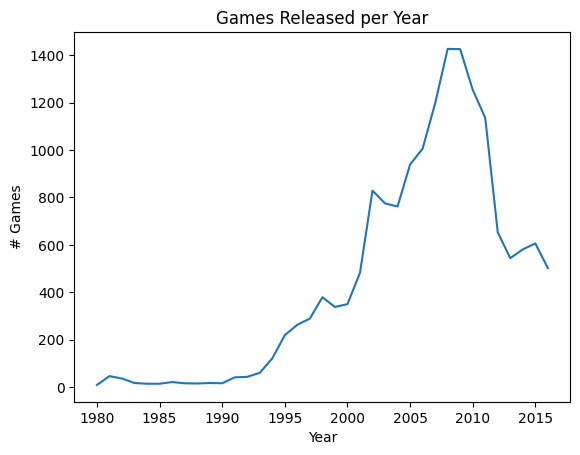

In [18]:
#Elige las plataformas con las mayores ventas totales y construye una distribución basada en los datos de cada año
games_per_year.plot(
    kind="line",
    xlabel="Year",
    ylabel="# Games",
    title="Games Released per Year"
)

plt.show()

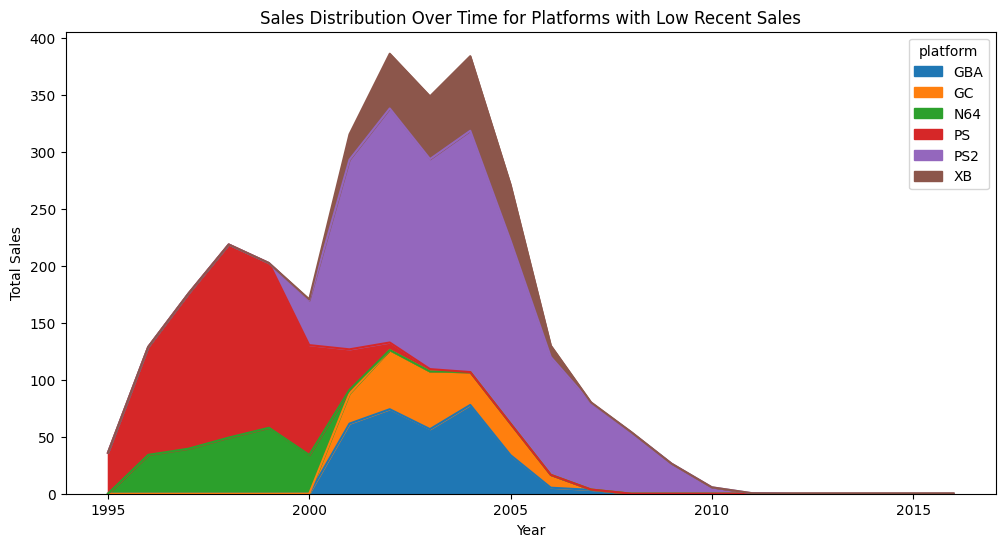

In [45]:
#Busca las plataformas que solían ser populares pero que ahora no tienen ventas
platforms_to_plot = ['GBA', 'GC', 'N64', 'PS', 'PS2', 'XB']

df_sales_per_platform = games.groupby(['year_of_release', 'platform'])['total_sales'].sum().unstack()
df_declining_platforms_sales = df_sales_per_platform[platforms_to_plot]


df_declining_platforms_sales.plot(kind='area', figsize=(12, 6))
plt.title('Sales Distribution Over Time for Platforms with Low Recent Sales')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.show()

#¿Cuánto tardan generalmente las nuevas plataformas en aparecer y las antiguas en desaparecer?

La vida útil de las plataformas promedio es de aproximadamente 6,3 años, con una mediana de 6 años. Un número significativo de plataformas tiene una vida útil de entre 5 y 10 años. Esto sugiere que las nuevas plataformas generalmente despegan y permanecen activas entre 6 y 10 años antes de que su popularidad disminuya y las ventas disminuyan significativamente

#Determina para qué período debes tomar datos. Para hacerlo mira tus respuestas a las preguntas anteriores. Los datos deberían permitirte construir un modelo para 2017

Como analizamos e implementamos en los pasos anteriores, hemos determinado que los datos de 2012 a 2016 son el período más relevante para construir un modelo para 2017. Este período captura las tendencias recientes del mercado y el rendimiento de las plataformas que probablemente estarán activas en 2017.


In [53]:
# datos 2012 , 2016
recent_games_data = games[(games['year_of_release'] >= 2012) & (games['year_of_release'] <= 2016)].copy()

print("Data for the period 2012-2016:")
recent_games_data.info()
print("\nSample of the data for 2012-2016:")
display(recent_games_data.head())

Data for the period 2012-2016:
<class 'pandas.core.frame.DataFrame'>
Index: 2886 entries, 16 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             2886 non-null   object 
 1   platform         2886 non-null   object 
 2   year_of_release  2886 non-null   float64
 3   genre            2886 non-null   object 
 4   na_sales         2886 non-null   float64
 5   eu_sales         2886 non-null   float64
 6   jp_sales         2886 non-null   float64
 7   other_sales      2886 non-null   float64
 8   critic_score     2886 non-null   float64
 9   user_score       2886 non-null   float64
 10  rating           1611 non-null   object 
 11  total_sales      2886 non-null   float64
dtypes: float64(8), object(4)
memory usage: 293.1+ KB

Sample of the data for 2012-2016:


,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
16,Grand Theft Auto V,PS3,2013.0,Action,7.02,9.09,0.98,3.96,97.0,8.2,M,21.05
23,Grand Theft Auto V,X360,2013.0,Action,9.66,5.14,0.06,1.41,97.0,8.1,M,16.27
31,Call of Duty: Black Ops 3,PS4,2015.0,Shooter,6.03,5.86,0.36,2.38,71.0,7.5,NaN,14.63
33,Pokemon X/Pokemon Y,3DS,2013.0,Role-Playing,5.28,4.19,4.35,0.78,71.0,7.5,NaN,14.60
34,Call of Duty: Black Ops II,PS3,2012.0,Shooter,4.99,5.73,0.65,2.42,83.0,5.3,M,13.79


In [51]:
#Ahora trabajaremos con el DataFrame recent_games_data (2012-2016)
print(recent_games_data.head())

                          name platform  year_of_release         genre  \
16          Grand Theft Auto V      PS3           2013.0        Action   
23          Grand Theft Auto V     X360           2013.0        Action   
31   Call of Duty: Black Ops 3      PS4           2015.0       Shooter   
33         Pokemon X/Pokemon Y      3DS           2013.0  Role-Playing   
34  Call of Duty: Black Ops II      PS3           2012.0       Shooter   

    na_sales  eu_sales  jp_sales  other_sales  critic_score  user_score  \
16      7.02      9.09      0.98         3.96          97.0         8.2   
23      9.66      5.14      0.06         1.41          97.0         8.1   
31      6.03      5.86      0.36         2.38          71.0         7.5   
33      5.28      4.19      4.35         0.78          71.0         7.5   
34      4.99      5.73      0.65         2.42          83.0         5.3   

   rating  total_sales  
16      M        21.05  
23      M        16.27  
31    NaN        14.63  
33  

#¿Qué plataformas son líderes en ventas? ¿Cuáles crecen y cuáles se reducen? Elige varias plataformas potencialmente rentables

In [58]:
# Calcular las ventas totales por plataforma en el período reciente (2012-2016)
platform_sales_2012_2016 = recent_games_data.groupby('platform')['total_sales'].sum().sort_values(ascending=False)

print("Total Sales per Platform (2012-2016):")
print(platform_sales_2012_2016)

Total Sales per Platform (2012-2016):
platform
PS4     314.14
PS3     288.79
X360    236.54
3DS     194.61
XOne    159.32
WiiU     82.19
PC       62.65
PSV      49.18
Wii      35.37
DS       12.55
PSP      11.19
Name: total_sales, dtype: float64



Yearly Sales for Top Platforms (2012-2016):


platform,3DS,PS3,PS4,X360,XOne
year_of_release,,,,,
2012.0,51.36,107.36,NaN,99.74,NaN
2013.0,56.57,113.25,25.99,88.58,18.96
2014.0,43.76,47.76,100.00,34.74,54.07
2015.0,27.78,16.82,118.90,11.96,60.14
2016.0,15.14,3.60,69.25,1.52,26.15


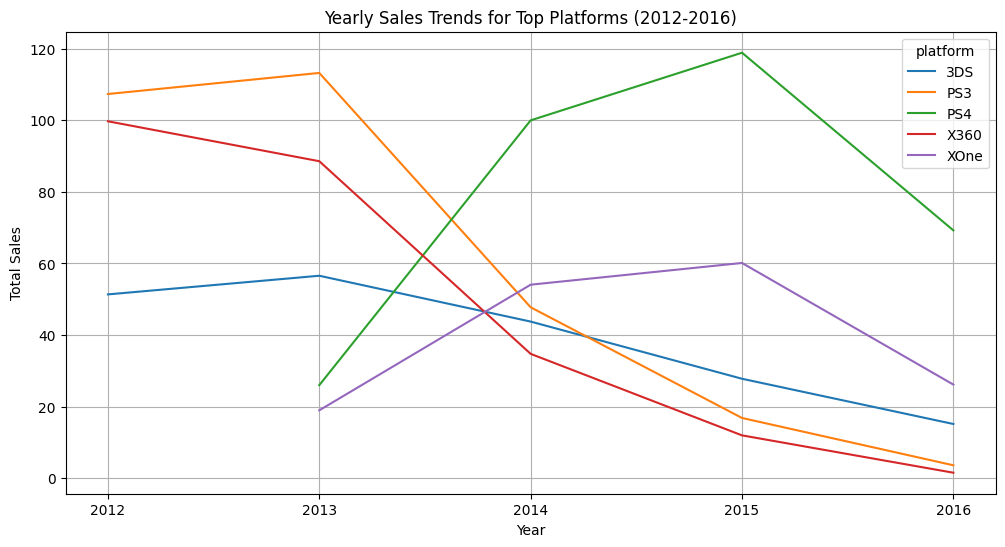

In [59]:
top_platforms_recent = platform_sales_2012_2016.head().index.tolist()

top_platforms_recent_data = recent_games_data[recent_games_data['platform'].isin(top_platforms_recent)]

yearly_sales_top_platforms = top_platforms_recent_data.groupby(['year_of_release', 'platform'])['total_sales'].sum().unstack()

print("\nYearly Sales for Top Platforms (2012-2016):")
display(yearly_sales_top_platforms)

yearly_sales_top_platforms.plot(kind='line', figsize=(12, 6))
plt.title('Yearly Sales Trends for Top Platforms (2012-2016)')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.xticks(yearly_sales_top_platforms.index)
plt.grid(True)
plt.show()

#¿Cuáles crecen y cuáles se reducen?

Basándonos en las principales plataformas de 2012 a 2016, podemos identificar qué plataformas estaban creciendo y cuáles se estaban reduciendo durante ese período:

Plataformas en crecimiento:
PS4: Muestra una fuerte tendencia al alza en las ventas desde su lanzamiento a finales de 2013 hasta 2015, aunque hay una caída en 2016..
XOne: También muestra crecimiento desde su lanzamiento a finales de 2013, con un aumento de las ventas hasta 2015. una caida en 2016.
Plataformas en reducción:
PS3: Muestra una disminución significativa en las ventas de 2012 a 2016.
X360: También muestra una fuerte disminución en las ventas durante este período.
3DS: Aunque comenzó con fuerza en 2012, sus ventas muestran una tendencia a la baja en los últimos años de este período.

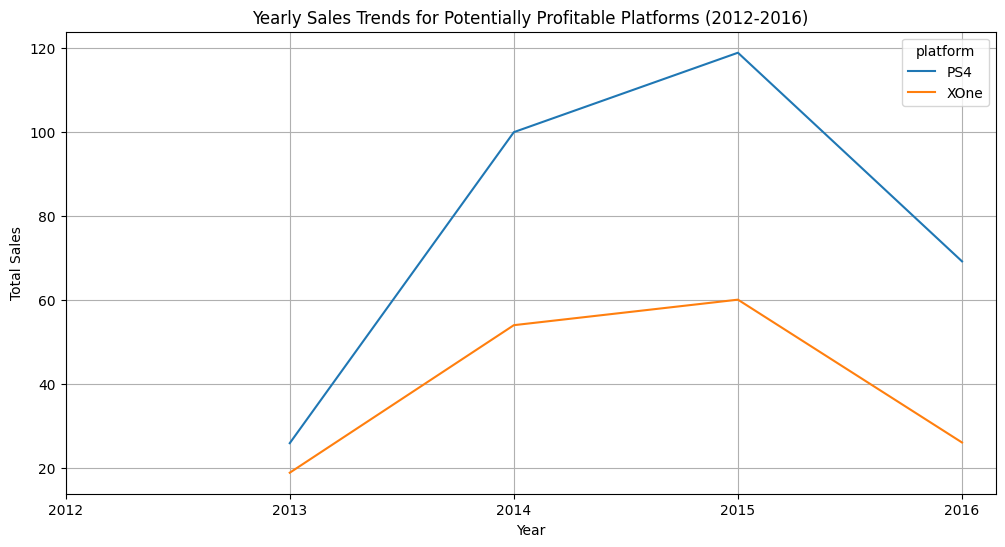

In [61]:
#Seleccione las plataformas potencialmente rentables
profitable_platforms = ['PS4', 'XOne']

profitable_platforms_sales = yearly_sales_top_platforms[profitable_platforms]

profitable_platforms_sales.plot(kind='line', figsize=(12, 6))
plt.title('Yearly Sales Trends for Potentially Profitable Platforms (2012-2016)')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.xticks(profitable_platforms_sales.index)
plt.grid(True)
plt.show()

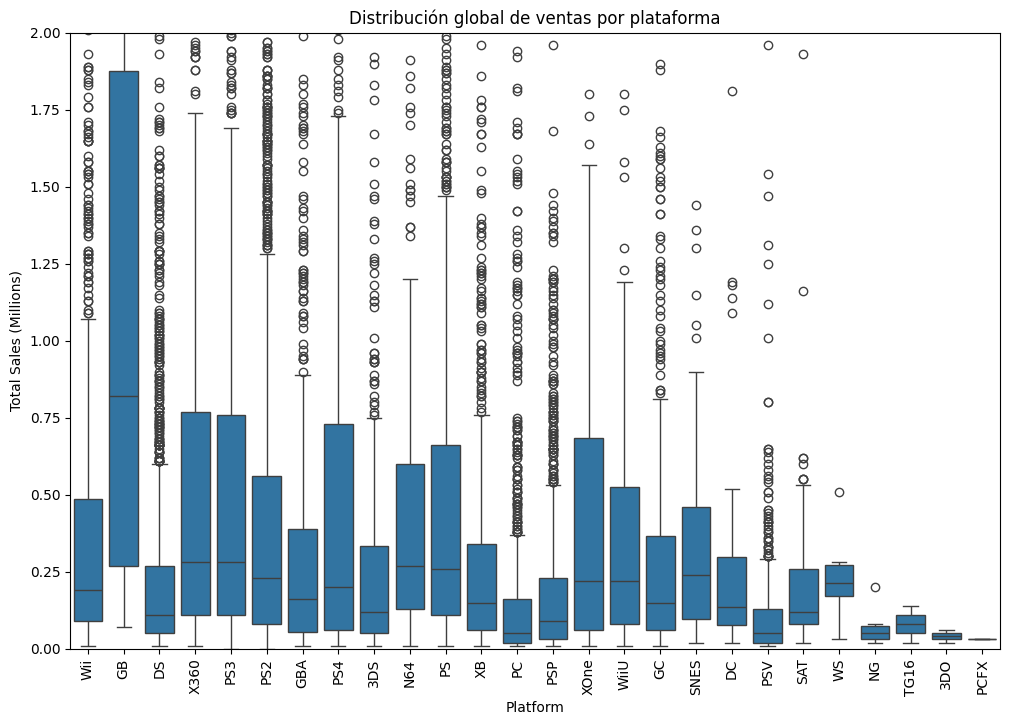

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(12, 8))
sns.boxplot(x='platform', y='total_sales', data=games)
plt.title('Distribución global de ventas por plataforma')
plt.xlabel('Platform')
plt.ylabel('Total Sales (Millions)')
plt.xticks(rotation=90)
plt.ylim(0, 2)
plt.show()

#¿Son significativas las diferencias en las ventas?


Se observan diferencias significativas
Esto es lo que indica el diagrama de cajas:

Medianas diferentes:Se puede observar que la mediana de ventas varía considerablemente entre plataformas. Algunas plataformas tienen una cifra de ventas típica más alta que otras.
El tamaño de las cajas y los bigotes también varían. Esto indica que la variabilidad en las ventas varía entre plataformas. Algunas plataformas tienen un conjunto más reducido de cifras de ventas, mientras que otras tienen una mayor dispersión.
Los puntos por encima o por debajo de los bigotes representan valores atípicos. La presencia y la magnitud de estos valores atípicos también difieren considerablemente entre plataformas, lo que indica que algunas plataformas tienen algunos títulos superventas que venden mucho más que el juego típico en esa plataforma.

#¿Qué sucede con las ventas promedio en varias plataformas? Describe tus hallazgos

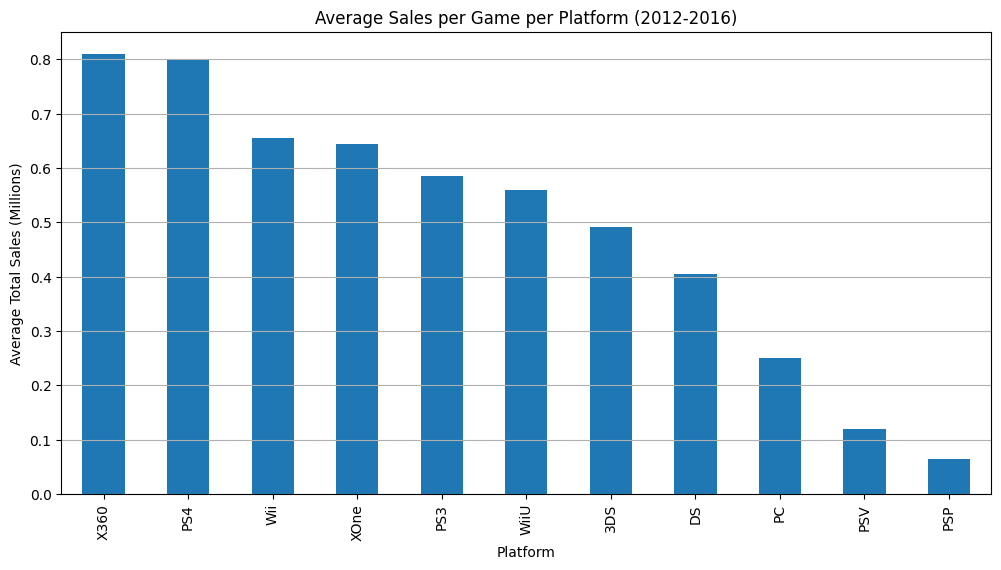

In [67]:
#Graficar las ventas promedio por plataforma
plt.figure(figsize=(12, 6))
average_sales_per_platform_recent.plot(kind='bar')
plt.title('Average Sales per Game per Platform (2012-2016)')
plt.xlabel('Platform')
plt.ylabel('Average Total Sales (Millions)')
plt.xticks(rotation=90)
plt.grid(axis='y')
plt.show()

Las plataformas con las mayores ventas promedio por juego fueron Xbox 360, seguida de cerca por PS4, y luego Wii, Xbox One y PS3. Esto indica que, en promedio, los juegos lanzados en estas plataformas tuvieron mayores ventas durante este período en comparación con otras.
Plataformas como 3DS, DS, PC, PSV y PSP tuvieron ventas promedio por juego significativamente menores.
Si bien PS4 y Xbox One tuvieron altas ventas totales debido a su crecimiento y número de lanzamientos en los últimos años, plataformas como Xbox 360 y PS3, a pesar de la disminución en sus ventas totales, aún tuvieron un promedio de ventas por juego relativamente alto en este período.

#Crea un gráfico de dispersión y calcula la correlación entre las reseñas y las ventas.

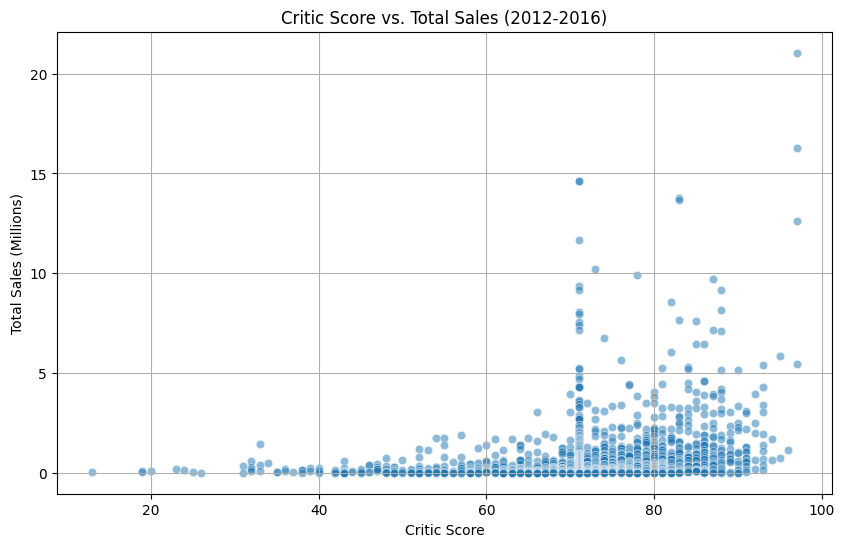

In [68]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='critic_score', y='total_sales', data=recent_games_data, alpha=0.5)
plt.title('Critic Score vs. Total Sales (2012-2016)')
plt.xlabel('Critic Score')
plt.ylabel('Total Sales (Millions)')
plt.grid(True)
plt.show()

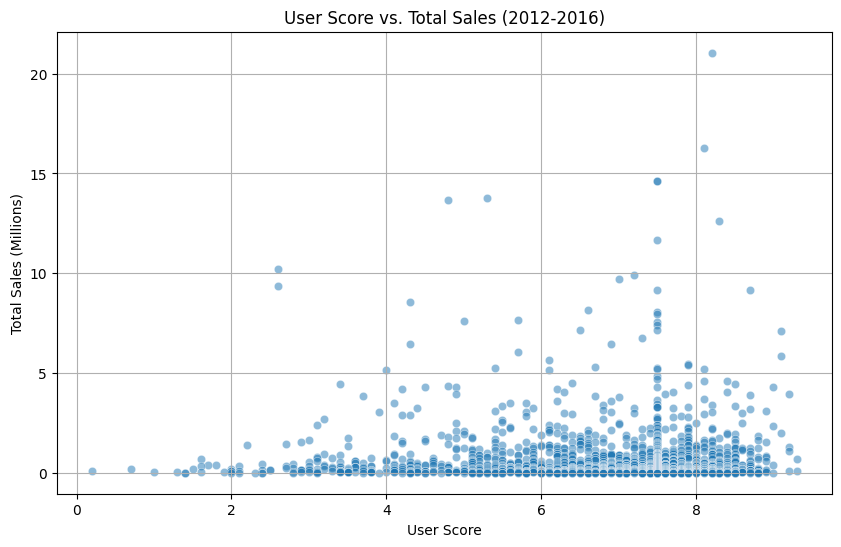

In [69]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='user_score', y='total_sales', data=recent_games_data, alpha=0.5)
plt.title('User Score vs. Total Sales (2012-2016)')
plt.xlabel('User Score')
plt.ylabel('Total Sales (Millions)')
plt.grid(True)
plt.show()

In [70]:
critic_score_correlation = recent_games_data['critic_score'].corr(recent_games_data['total_sales'])
user_score_correlation = recent_games_data['user_score'].corr(recent_games_data['total_sales'])

print(f"Correlation between Critic Score and Total Sales: {critic_score_correlation:.2f}")
print(f"Correlation between User Score and Total Sales: {user_score_correlation:.2f}")

Correlation between Critic Score and Total Sales: 0.27
Correlation between User Score and Total Sales: -0.06


La puntuación de la crítica y las ventas totales es de 0,27, lo que indica una correlación positiva débil.
La correlación entre la puntuación de los usuarios y las ventas totales es de -0,06, lo que indica una correlación negativa muy débil.
Ni las puntuaciones de la crítica ni las de los usuarios parecen ser importantes para las ventas totales de los juegos lanzados entre 2012 y 2016.

#Teniendo en cuenta tus conclusiones compara las ventas de los mismos juegos en otras plataformas

In [ ]:
platform_counts = recent_games_data.groupby('name')['platform'].nunique()
multi_platform_games = platform_counts[platform_counts > 1].index.tolist()
print(f"Number of multi-platform games: {len(multi_platform_games)}")
print("Sample of multi-platform games:")
print(multi_platform_games[:10])

Number of multi-platform games: 596
Sample of multi-platform games:
[" Frozen: Olaf's Quest", '2014 FIFA World Cup Brazil', '3rd Super Robot Wars Z Jigoku Hen', '3rd Super Robot Wars Z: Tengoku-Hen', '7 Days to Die', 'AKB1/149: Love Election', 'Abunai: Koi no Sousa Shitsu', 'Accel World: Ginyoku no Kakusei', 'Accel World: Kasoku no Chouten', "Adventure Time: Explore the Dungeon Because I Don't Know!"]


In [72]:
multi_platform_sales_data = recent_games_data[recent_games_data['name'].isin(multi_platform_games)].copy()
multi_platform_sales_summary = multi_platform_sales_data.groupby(['name', 'platform'])['total_sales'].sum().reset_index()

for game_name in multi_platform_games:
    game_sales = multi_platform_sales_summary[multi_platform_sales_summary['name'] == game_name]
    print(f"Sales for '{game_name}':")
    for index, row in game_sales.iterrows():
        print(f"  - {row['platform']}: {row['total_sales']:.2f}")
    print("-" * 20)

Sales for ' Frozen: Olaf's Quest':
  - 3DS: 0.59
  - DS: 0.51
--------------------
Sales for '2014 FIFA World Cup Brazil':
  - PS3: 0.61
  - X360: 0.43
--------------------
Sales for '3rd Super Robot Wars Z Jigoku Hen':
  - PS3: 0.23
  - PSV: 0.19
--------------------
Sales for '3rd Super Robot Wars Z: Tengoku-Hen':
  - PS3: 0.15
  - PSV: 0.19
--------------------
Sales for '7 Days to Die':
  - PS4: 0.14
  - XOne: 0.05
--------------------
Sales for 'AKB1/149: Love Election':
  - PS3: 0.08
  - PSP: 0.23
  - PSV: 0.07
--------------------
Sales for 'Abunai: Koi no Sousa Shitsu':
  - PSP: 0.01
  - PSV: 0.02
--------------------
Sales for 'Accel World: Ginyoku no Kakusei':
  - PS3: 0.03
  - PSP: 0.03
--------------------
Sales for 'Accel World: Kasoku no Chouten':
  - PS3: 0.02
  - PSP: 0.01
--------------------
Sales for 'Adventure Time: Explore the Dungeon Because I Don't Know!':
  - 3DS: 0.14
  - PS3: 0.04
  - WiiU: 0.03
  - X360: 0.08
--------------------
Sales for 'Adventure Time: Fi

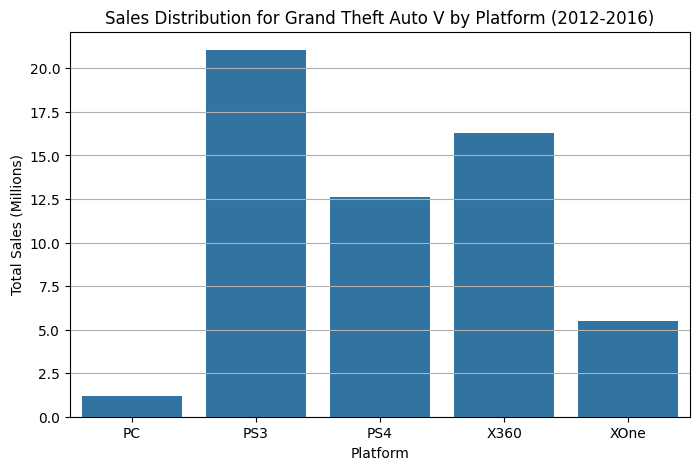

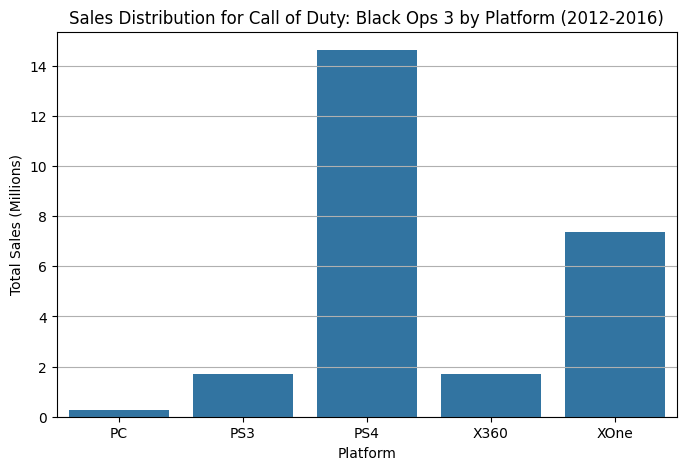

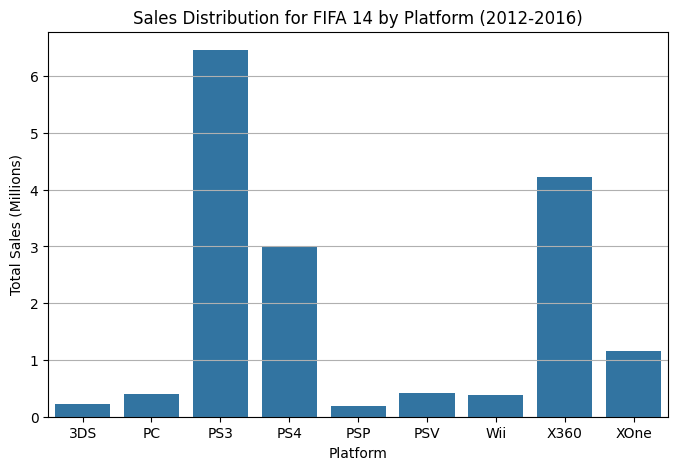

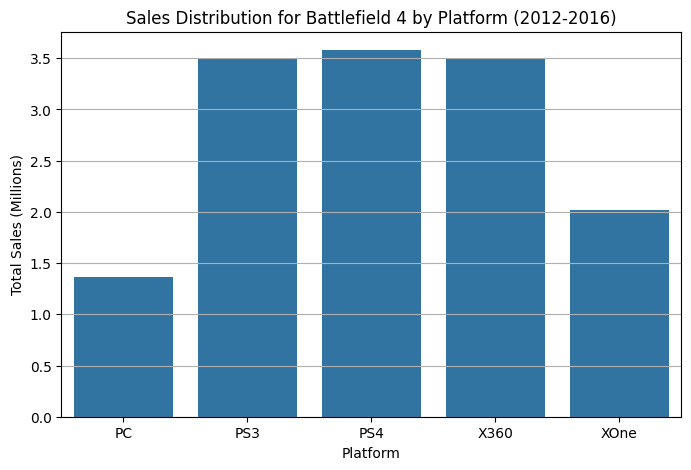

In [73]:
notable_multi_platform_games = [
    'Grand Theft Auto V',
    'Call of Duty: Black Ops 3',
    'FIFA 14',
    'Battlefield 4'
]

for game_name in notable_multi_platform_games:
    game_sales_data = multi_platform_sales_summary[multi_platform_sales_summary['name'] == game_name]

    plt.figure(figsize=(8, 5))
    sns.barplot(x='platform', y='total_sales', data=game_sales_data)
    plt.title(f'Sales Distribution for {game_name} by Platform (2012-2016)')
    plt.xlabel('Platform')
    plt.ylabel('Total Sales (Millions)')
    plt.grid(axis='y')
    plt.show()

Las ventas de un mismo juego multiplataforma pueden variar significativamente entre plataformas.
Para los juegos visualizados:
"Grand Theft Auto V" mostró ventas mucho mayores en PS4 y Xbox One en comparación con otras plataformas.
"Call of Duty: Black Ops 3" tuvo las mayores ventas en PS4, seguido de Xbox One.
"FIFA 14" tuvo fuertes ventas en PS3, Xbox 360 y PS4.
"Battlefield 4" también mostró ventas notables en PS4, Xbox One, PS3 y Xbox 360.

#Distribución general de los juegos por género

¿Qué se puede decir de los géneros más rentables?

In [77]:
# Calcular las ventas totales por género en el período reciente (2012-2016)
genre_sales_2012_2016 = recent_games_data.groupby('genre')['total_sales'].sum().sort_values(ascending=False)

print("Total Sales per Genre (2012-2016):")
print(genre_sales_2012_2016)

Total Sales per Genre (2012-2016):
genre
Action          441.12
Shooter         304.73
Role-Playing    192.80
Sports          181.07
Misc             85.04
Platform         61.00
Racing           53.50
Fighting         44.49
Simulation       35.12
Adventure        29.43
Strategy         13.34
Puzzle            4.89
Name: total_sales, dtype: float64


#Crea un perfil de usuario para cada región

In [79]:
# Calcular las ventas totales por plataforma para cada región en el período reciente (2012-2016)
regional_platform_sales = recent_games_data.groupby('platform')[['na_sales', 'eu_sales', 'jp_sales']].sum()

top_platforms_na = regional_platform_sales['na_sales'].sort_values(ascending=False).head(5)
top_platforms_eu = regional_platform_sales['eu_sales'].sort_values(ascending=False).head(5)
top_platforms_jp = regional_platform_sales['jp_sales'].sort_values(ascending=False).head(5)

print("Top 5 Platforms in North America (2012-2016):")
print(top_platforms_na)

print("\nTop 5 Platforms in Europe (2012-2016):")
print(top_platforms_eu)

print("\nTop 5 Platforms in Japan (2012-2016):")
print(top_platforms_jp)

Top 5 Platforms in North America (2012-2016):
platform
X360    140.05
PS4     108.74
PS3     103.38
XOne     93.12
3DS      55.31
Name: na_sales, dtype: float64

Top 5 Platforms in Europe (2012-2016):
platform
PS4     141.09
PS3     106.86
X360     74.52
XOne     51.59
3DS      42.64
Name: eu_sales, dtype: float64

Top 5 Platforms in Japan (2012-2016):
platform
3DS     87.79
PS3     35.29
PSV     21.04
PS4     15.96
WiiU    13.01
Name: jp_sales, dtype: float64


Norteamérica (NA) y Europa (UE): Estas dos regiones muestran preferencias de género similares en su top 5. Acción, Shooter, Deportes y RPG se encuentran entre los géneros más populares en ambas regiones. El orden y las cifras de ventas específicas difieren. Misc se encuentra entre los 5 principales en Norteamérica, mientras que Racing se encuentra entre los 5 principales en Europa, con una ligera variación.
Japón (JP): Las preferencias de género en Japón son notablemente diferentes a las de Norteamérica y Europa. RPG es el género más popular. La acción también es popular, pero géneros como Misc, Simulación y Lucha se encuentran entre los 5 principales, siendo menos prominentes en los géneros principales de Norteamérica y Europa. Shooter y Deportes, que son muy populares en Norteamérica y Europa, tienen ventas mucho menores y no se encuentran entre los 5 principales en Japón. En resumen, Norteamérica y Europa comparten gustos similares, dominados por los juegos de acción, disparos, deportes y rol, mientras que Japón muestra una clara preferencia por los juegos de rol y un mayor interés en géneros como simulación y lucha, en comparación con las otras dos regiones.

#Si las clasificaciones de ESRB afectan a las ventas en regiones individuales

In [81]:
# Calculate total sales per rating for each region in the recent period (2012-2016)
regional_rating_sales = recent_games_data.groupby('rating')[['na_sales', 'eu_sales', 'jp_sales']].sum()

print("Total Sales by ESRB Rating per Region (2012-2016):")
display(regional_rating_sales)

# Analyze the impact of ratings on sales in each region
print("\nAnalysis of ESRB Rating Impact on Sales per Region:")

# North America
print("\nNorth America:")
print(regional_rating_sales['na_sales'].sort_values(ascending=False))

# Europe
print("\nEurope:")
print(regional_rating_sales['eu_sales'].sort_values(ascending=False))

# Japan
print("\nJapan:")
print(regional_rating_sales['jp_sales'].sort_values(ascending=False))

Total Sales by ESRB Rating per Region (2012-2016):


,na_sales,eu_sales,jp_sales
rating,,,
E,114.37,113.03,28.33
E10+,75.70,55.37,8.19
M,231.57,193.96,21.20
T,66.02,52.96,26.02



Analysis of ESRB Rating Impact on Sales per Region:

North America:
rating
M       231.57
E       114.37
E10+     75.70
T        66.02
Name: na_sales, dtype: float64

Europe:
rating
M       193.96
E       113.03
E10+     55.37
T        52.96
Name: eu_sales, dtype: float64

Japan:
rating
E       28.33
T       26.02
M       21.20
E10+     8.19
Name: jp_sales, dtype: float64


Tanto en Norteamérica como en Europa, la clasificación "M" (para adultos) registra sistemáticamente las mayores ventas totales con una diferencia significativa. Le siguen "E" (para todos), "E10+" (para mayores de 10 años) y, por último, "T" (para adolescentes). Esto sugiere que los juegos clasificados para adultos, que suelen incluir títulos populares de acción y disparos, son los principales impulsores de ventas en estas regiones.

El patrón en Japón es diferente. La clasificación "E" (Para todos) registra las mayores ventas, seguida de cerca por la "T" (Adolescentes). La clasificación "M" (Maduro) registra menores ventas en comparación con las clasificaciones E y T en Japón.
Esto indica que en Japón, los juegos para todas las edades y adolescentes son más populares en términos de ventas totales que los juegos con clasificación M.

In [88]:
print("Hipótesis nula (H0): La calificación promedio de los usuarios para la plataforma Xbox One es igual a la calificación promedio de los usuarios para la plataforma PC.")
print("Hipótesis alternativa (H1): La calificación promedio de los usuarios para la plataforma Xbox One no es igual a la calificación promedio de los usuarios para la plataforma PC.")

Hipótesis nula (H0): La calificación promedio de los usuarios para la plataforma Xbox One es igual a la calificación promedio de los usuarios para la plataforma PC.
Hipótesis alternativa (H1): La calificación promedio de los usuarios para la plataforma Xbox One no es igual a la calificación promedio de los usuarios para la plataforma PC.


In [89]:
xone_user_scores = recent_games_data[recent_games_data['platform'] == 'XOne']['user_score']
pc_user_scores = recent_games_data[recent_games_data['platform'] == 'PC']['user_score']

print("User scores for Xbox One:")
print(xone_user_scores.head())
print("\nUser scores for PC:")
print(pc_user_scores.head())

User scores for Xbox One:
99     7.5
165    7.9
179    5.4
242    6.4
270    6.2
Name: user_score, dtype: float64

User scores for PC:
192     4.0
458     3.9
688     7.9
959     4.8
1095    7.9
Name: user_score, dtype: float64


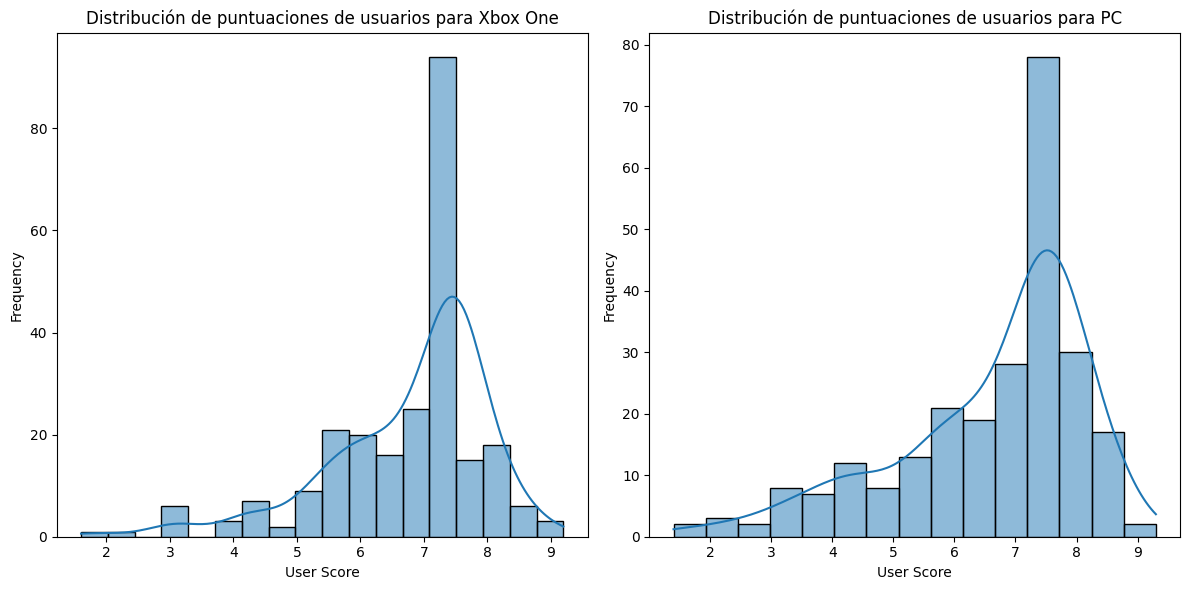

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(xone_user_scores.dropna(), kde=True)
plt.title('Distribución de puntuaciones de usuarios para Xbox One')
plt.xlabel('User Score')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(pc_user_scores.dropna(), kde=True)
plt.title('Distribución de puntuaciones de usuarios para PC')
plt.xlabel('User Score')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [93]:
shapiro_test_xone = stats.shapiro(xone_user_scores.dropna())
shapiro_test_pc = stats.shapiro(pc_user_scores.dropna())

levene_test = stats.levene(xone_user_scores.dropna(), pc_user_scores.dropna())

print(f"Prueba Shapiro-Wilk para puntuaciones de usuarios de Xbox One: Estadística={shapiro_test_xone.statistic:.4f}, p-value={shapiro_test_xone.pvalue:.4f}")
print(f"Prueba Shapiro-Wilk para puntuaciones de usuarios de PC: Estadística={shapiro_test_pc.statistic:.4f}, p-value={shapiro_test_pc.pvalue:.4f}")
print(f"Prueba de Levene para varianzas iguales: estadística={levene_test.statistic:.4f}, p-value={levene_test.pvalue:.4f}")

Prueba Shapiro-Wilk para puntuaciones de usuarios de Xbox One: Estadística=0.8858, p-value=0.0000
Prueba Shapiro-Wilk para puntuaciones de usuarios de PC: Estadística=0.8943, p-value=0.0000
Prueba de Levene para varianzas iguales: estadística=6.6633, p-value=0.0101


In [94]:
from scipy.stats import ttest_ind

statistic, p_value = ttest_ind(xone_user_scores.dropna(), pc_user_scores.dropna(), equal_var=False)

print(f"T-test statistic: {statistic:.4f}")
print(f"P-value: {p_value:.4f}")

T-test statistic: 1.2697
P-value: 0.2048


In [97]:
alpha = 0.05

print(f"Nivel de significancia (alpha): {alpha}")
print(f"P-value: {p_value:.4f}")

if p_value < alpha:
    print("\nCon base en el valor p, rechazamos la hipótesis nula.")
    print("Conclusion:Hay una diferencia estadísticamente significativa en las calificaciones promedio de los usuarios entre las plataformas Xbox One y PC.")
else:
    print("\nCon base en el valor p, no podemos rechazar la hipótesis nula.")
    print("Conclusion: No hay suficiente evidencia para sugerir una diferencia estadísticamente significativa en las calificaciones promedio de los usuarios entre las plataformas Xbox One y PC.")

print("\nInterpretation:")
print(f"El valor p de {p_value:.4f} representa la probabilidad de observar una estadística de prueba tan extrema o más extrema que la calculada a partir de nuestros datos, suponiendo que la hipótesis nula es verdadera (es decir, las calificaciones promedio de los usuarios de Xbox One y PC son las mismas).")
print(f"Dado que el valor p ({p_value:.4f}) es mayor que nuestro nivel de significancia elegido (alpha = {alpha}), no tenemos evidencia suficiente para rechazar la hipótesis nula).")
print("Por lo tanto, con base en los datos disponibles y la prueba t de muestras independientes, concluimos que no existe una diferencia estadísticamente significativa en las calificaciones promedio de los usuarios entre las plataformas Xbox One y PC.")

Nivel de significancia (alpha): 0.05
P-value: 0.2048

Con base en el valor p, no podemos rechazar la hipótesis nula.
Conclusion: No hay suficiente evidencia para sugerir una diferencia estadísticamente significativa en las calificaciones promedio de los usuarios entre las plataformas Xbox One y PC.

Interpretation:
El valor p de 0.2048 representa la probabilidad de observar una estadística de prueba tan extrema o más extrema que la calculada a partir de nuestros datos, suponiendo que la hipótesis nula es verdadera (es decir, las calificaciones promedio de los usuarios de Xbox One y PC son las mismas).
Dado que el valor p (0.2048) es mayor que nuestro nivel de significancia elegido (alpha = 0.05), no tenemos evidencia suficiente para rechazar la hipótesis nula).
Por lo tanto, con base en los datos disponibles y la prueba t de muestras independientes, concluimos que no existe una diferencia estadísticamente significativa en las calificaciones promedio de los usuarios entre las plataforma

#Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes

In [98]:
print("Hipótesis nula (H0): La calificación promedio de los usuarios para el género Acción es igual a la calificación promedio de los usuarios para el género Deportes.")
print("Hipótesis alternativa (H1): La calificación promedio de los usuarios para el género Acción no es igual a la calificación promedio de los usuarios para el género Deportes.")

Hipótesis nula (H0): La calificación promedio de los usuarios para el género Acción es igual a la calificación promedio de los usuarios para el género Deportes.
Hipótesis alternativa (H1): La calificación promedio de los usuarios para el género Acción no es igual a la calificación promedio de los usuarios para el género Deportes.


In [99]:
action_user_scores = recent_games_data[recent_games_data['genre'] == 'Action']['user_score']
sports_user_scores = recent_games_data[recent_games_data['genre'] == 'Sports']['user_score']

print("User scores for Action genre:")
display(action_user_scores.head())
print("\nUser scores for Sports genre:")
display(sports_user_scores.head())

User scores for Action genre:


,user_score
16,8.2
23,8.1
42,8.3
81,6.6
127,6.9



User scores for Sports genre:


,user_score
77,4.3
94,5.0
126,4.3
143,5.7
264,4.5


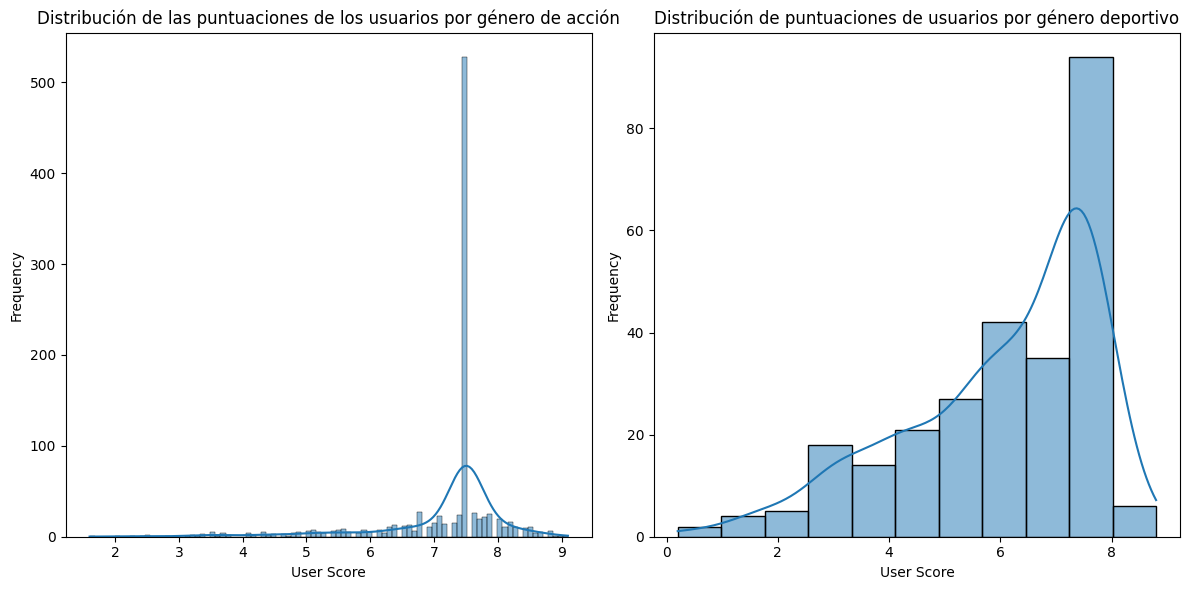

Prueba de Shapiro-Wilk para puntuaciones de usuarios del género Acción: Estadística=0.7141, p-value=0.0000
Prueba de Shapiro-Wilk para puntuaciones de usuarios del género Deportes: Estadística=0.8871, p-value=0.0000
Prueba de Levene para varianzas iguales: estadística=156.1422, p-value=0.0000


In [107]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(action_user_scores.dropna(), kde=True)
plt.title('Distribución de las puntuaciones de los usuarios por género de acción')
plt.xlabel('User Score')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(sports_user_scores.dropna(), kde=True)
plt.title('Distribución de puntuaciones de usuarios por género deportivo')
plt.xlabel('User Score')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

shapiro_test_action = stats.shapiro(action_user_scores.dropna())
shapiro_test_sports = stats.shapiro(sports_user_scores.dropna())

levene_test = stats.levene(action_user_scores.dropna(), sports_user_scores.dropna())

print(f"Prueba de Shapiro-Wilk para puntuaciones de usuarios del género Acción: Estadística={shapiro_test_action.statistic:.4f}, p-value={shapiro_test_action.pvalue:.4f}")
print(f"Prueba de Shapiro-Wilk para puntuaciones de usuarios del género Deportes: Estadística={shapiro_test_sports.statistic:.4f}, p-value={shapiro_test_sports.pvalue:.4f}")
print(f"Prueba de Levene para varianzas iguales: estadística={levene_test.statistic:.4f}, p-value={levene_test.pvalue:.4f}")

In [111]:
statistic, p_value = stats.ttest_ind(action_user_scores.dropna(), sports_user_scores.dropna(), equal_var=False)

print(f"T-estadística de prueba: {statistic:.4f}")
print(f"P-value: {p_value:.4f}")

alpha = 0.05

print(f"\nNivel de significancia (alpha): {alpha}")
print(f"P-value: {p_value:.4f}")

if p_value < alpha:
    print("\nCon base en el valor p, rechazamos la hipótesis nula.")
    print("Conclusion:Existe una diferencia estadísticamente significativa en las puntuaciones promedio de los usuarios entre los géneros Acción y Deportes.")
else:
    print("\nCon base en el valor p, no podemos rechazar la hipótesis nula.")
    print("Conclusion: No hay suficiente evidencia para sugerir una diferencia estadísticamente significativa en las puntuaciones promedio de los usuarios entre los géneros de Acción y Deportes.")

print("\nInterpretación:")
print(f"El valor p de {p_value:.4f} representa la probabilidad de observar una estadística de prueba tan extrema o más extrema que la calculada a partir de nuestros datos, suponiendo que la hipótesis nula es verdadera (es decir, los puntajes promedio de los usuarios para los géneros Acción y Deportes son los mismos")
print(f"Dado que el valor p ({p_value:.4f}) es mayor que nuestro nivel de significancia elegido (alpha = {alpha}), no tenemos evidencia suficiente para rechazar la hipótesis nula).")
print("Por lo tanto, con base en los datos disponibles y la prueba t de muestras independientes, concluimos que {'hay' si p_valor < alpha de lo contrario 'no hay'} una diferencia estadísticamente significativa en las puntuaciones promedio de los usuarios entre los géneros de Acción y Deportes.")

T-estadística de prueba: 10.3083
P-value: 0.0000

Nivel de significancia (alpha): 0.05
P-value: 0.0000

Con base en el valor p, rechazamos la hipótesis nula.
Conclusion:Existe una diferencia estadísticamente significativa en las puntuaciones promedio de los usuarios entre los géneros Acción y Deportes.

Interpretación:
El valor p de 0.0000 representa la probabilidad de observar una estadística de prueba tan extrema o más extrema que la calculada a partir de nuestros datos, suponiendo que la hipótesis nula es verdadera (es decir, los puntajes promedio de los usuarios para los géneros Acción y Deportes son los mismos
Dado que el valor p (0.0000) es mayor que nuestro nivel de significancia elegido (alpha = 0.05), no tenemos evidencia suficiente para rechazar la hipótesis nula).
Por lo tanto, con base en los datos disponibles y la prueba t de muestras independientes, concluimos que {'hay' si p_valor < alpha de lo contrario 'no hay'} una diferencia estadísticamente significativa en las punt

In [112]:
shapiro_test_action = stats.shapiro(action_user_scores.dropna())
shapiro_test_sports = stats.shapiro(sports_user_scores.dropna())

levene_test = stats.levene(action_user_scores.dropna(), sports_user_scores.dropna())

print(f"Prueba de Shapiro-Wilk para puntuaciones de usuarios del género Acción: Estadística={shapiro_test_action.statistic:.4f}, p-value={shapiro_test_action.pvalue:.4f}")
print(f"Prueba de Shapiro-Wilk para puntuaciones de usuarios del género Deportes: Estadística={shapiro_test_sports.statistic:.4f}, p-value={shapiro_test_sports.pvalue:.4f}")
print(f"Prueba de Levene para varianzas iguales: estadística={levene_test.statistic:.4f}, p-value={levene_test.pvalue:.4f}")

Prueba de Shapiro-Wilk para puntuaciones de usuarios del género Acción: Estadística=0.7141, p-value=0.0000
Prueba de Shapiro-Wilk para puntuaciones de usuarios del género Deportes: Estadística=0.8871, p-value=0.0000
Prueba de Levene para varianzas iguales: estadística=156.1422, p-value=0.0000


In [113]:
print("\nAnálisis de supuestos para muestras independientes T-test:")

if shapiro_test_action.pvalue < 0.05:
    print("La prueba de Shapiro-Wilk para las puntuaciones de los usuarios del género Acción indica no normalidad (p < 0.05).")
else:
    print("La prueba de Shapiro-Wilk para las puntuaciones de los usuarios del género Acción indica normalidad (p >= 0.05).")

if shapiro_test_sports.pvalue < 0.05:
    print("La prueba de Shapiro-Wilk para las puntuaciones de los usuarios del género Deportes indica no normalidad (p < 0.05).")
else:
    print("La prueba de Shapiro-Wilk para las puntuaciones de los usuarios del género Deportes indica normalidad (p >= 0.05).")

if levene_test.pvalue < 0.05:
    print("La prueba de Levene para varianzas iguales indica varianzas desiguales (p < 0.05).")
else:
    print("La prueba de Levene para varianzas iguales indica varianzas iguales (p >= 0.05).")

print("\nConclusión sobre los supuestos de la prueba t:")
print("Según las pruebas de Shapiro-Wilk, las distribuciones de puntuaciones de los usuarios de los géneros Acción y Deportes no se distribuyen normalmente (los valores p son 0,0000 para ambos.")
print("Además, la prueba de Levene indica que las varianzas de las puntuaciones de los usuarios para los dos géneros son significativamente diferentes (valor p = 0,0000).")
print("\nDada la violación de los supuestos de normalidad y varianza igual, una prueba t de muestras independientes puede no ser la prueba más apropiada..")
print("Una prueba no paramétrica, como la prueba U de Mann-Whitney, que no supone normalidad ni varianzas iguales, podría ser más adecuada para comparar las puntuaciones de los usuarios entre estos dos géneros..")


Análisis de supuestos para muestras independientes T-test:
La prueba de Shapiro-Wilk para las puntuaciones de los usuarios del género Acción indica no normalidad (p < 0.05).
La prueba de Shapiro-Wilk para las puntuaciones de los usuarios del género Deportes indica no normalidad (p < 0.05).
La prueba de Levene para varianzas iguales indica varianzas desiguales (p < 0.05).

Conclusión sobre los supuestos de la prueba t:
Según las pruebas de Shapiro-Wilk, las distribuciones de puntuaciones de los usuarios de los géneros Acción y Deportes no se distribuyen normalmente (los valores p son 0,0000 para ambos.
Además, la prueba de Levene indica que las varianzas de las puntuaciones de los usuarios para los dos géneros son significativamente diferentes (valor p = 0,0000).

Dada la violación de los supuestos de normalidad y varianza igual, una prueba t de muestras independientes puede no ser la prueba más apropiada..
Una prueba no paramétrica, como la prueba U de Mann-Whitney, que no supone norm

In [114]:
from scipy.stats import ttest_ind

statistic, p_value = ttest_ind(action_user_scores.dropna(), sports_user_scores.dropna(), equal_var=False)

print(f"T-test statistic: {statistic:.4f}")
print(f"P-value: {p_value:.4f}")

T-test statistic: 10.3083
P-value: 0.0000


In [105]:
alpha = 0.05

print(f"Nivel de significancia (alpha): {alpha}")
print(f"P-value: {p_value:.4f}")

if p_value < alpha:
    print("\nCon base en el valor p, rechazamos la hipótesis nula.")
    print("Conclusión: Hay una diferencia estadísticamente significativa en las calificaciones promedio de los usuarios entre los géneros Acción y Deportes.")
else:
    print("\nCon base en el valor p, no podemos rechazar la hipótesis nula.")
    print("Conclusión: No hay suficiente evidencia para sugerir una diferencia estadísticamente significativa en las calificaciones promedio de los usuarios entre los géneros Acción y Deportes.")

print("\nInterpretación:")
print(f"El valor p de {p_value:.4f} representa la probabilidad de observar una estadística de prueba tan extrema o más extrema que la calculada a partir de nuestros datos, suponiendo que la hipótesis nula es verdadera (es decir, las calificaciones promedio de los usuarios para los géneros Acción y Deportes son las mismas).")
print(f"Dado que el valor p ({p_value:.4f}) es {'menor que' if p_value < alpha else 'mayor o igual que'} nuestro nivel de significancia elegido (alpha = {alpha}), {'tenemos' if p_value < alpha else 'no tenemos'} evidencia suficiente para rechazar la hipótesis nula).")
print("Por lo tanto, con base en los datos disponibles y la prueba t de muestras independientes, concluimos que {'existe' if p_value < alpha else 'no existe'} una diferencia estadísticamente significativa en las calificaciones promedio de los usuarios entre los géneros Acción y Deportes.")

Nivel de significancia (alpha): 0.05
P-value: 0.0000

Con base en el valor p, rechazamos la hipótesis nula.
Conclusión: Hay una diferencia estadísticamente significativa en las calificaciones promedio de los usuarios entre los géneros Acción y Deportes.

Interpretación:
El valor p de 0.0000 representa la probabilidad de observar una estadística de prueba tan extrema o más extrema que la calculada a partir de nuestros datos, suponiendo que la hipótesis nula es verdadera (es decir, las calificaciones promedio de los usuarios para los géneros Acción y Deportes son las mismas).
Dado que el valor p (0.0000) es menor que nuestro nivel de significancia elegido (alpha = 0.05), tenemos evidencia suficiente para rechazar la hipótesis nula).
Por lo tanto, con base en los datos disponibles y la prueba t de muestras independientes, concluimos que {'existe' if p_value < alpha else 'no existe'} una diferencia estadísticamente significativa en las calificaciones promedio de los usuarios entre los géne